# 03b · The whole thing, from scratch — one file, no helpers

You've built every piece of a DDPM across notebooks 01–03, each with the
`nanodiffusion` package supplying prerequisites and answer keys. This notebook is
the **graduation**: the *entire* 2D diffusion model assembled in a single
self-contained file — **pure `torch`, `numpy`, `matplotlib`, and nothing else.**
Not one `nanodiffusion` import.

And this time we drop the swiss roll — we'll teach it to generate a **heart** 🖤,
a completely different shape, to make one thing unmistakable: *the exact same
~130 lines learn any 2D distribution you hand them.* Nothing below even knows what
shape it's drawing.

Read it top to bottom and you have the complete algorithm: data → schedule →
forward noising → network → loss → training → sampling. This is the nanoGPT
single-file moment — the thing you can point at and say *"I built a diffusion
model from scratch."*

> No TODOs here — it's the reference. Everything you implemented earlier, now in
> one place with no scaffolding underneath it.

## 0 · Imports and device

The only dependencies are the standard scientific stack. `torch` for tensors and
autograd, `numpy` to synthesize the toy data, `matplotlib` to look at it.

In [1]:
import math
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

def pick_device():
    if torch.cuda.is_available(): return torch.device("cuda")
    if torch.backends.mps.is_available(): return torch.device("mps")
    return torch.device("cpu")

device = pick_device()
torch.manual_seed(0); np.random.seed(0)
print("device:", device)

device: mps


## 1 · The data — a 2D heart

Our dataset is 8000 points filling a heart shape, normalized to roughly zero mean
and unit variance. Each row is one 2D "example" — the stand-in for one image. We
build it by **rejection sampling** the classic heart inequality
$(x^2+y^2-1)^3 - x^2 y^3 < 0$: throw darts at a box, keep the ones that land inside.

We also define `points_from_text`, which turns *any* word or symbol into a point
cloud by rendering it and sampling its dark pixels — so you can generate your own
shapes (see the Explore note).

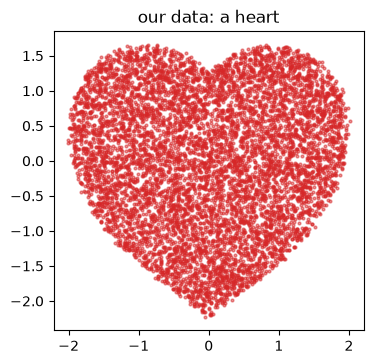

In [2]:
def heart(n):
    pts = []
    while len(pts) < n:                                  # rejection sampling
        xy = np.random.uniform(-1.5, 1.5, (4 * n, 2))
        x, y = xy[:, 0], xy[:, 1]
        inside = (x**2 + y**2 - 1) ** 3 - x**2 * y**3 < 0
        pts.extend(xy[inside].tolist())
    pts = np.array(pts[:n]) + 0.01 * np.random.randn(n, 2)
    pts = (pts - pts.mean(0)) / (pts.std() + 1e-8)        # normalize
    return torch.from_numpy(pts.astype(np.float32))

def points_from_text(text, n, fontsize=180):
    fig = plt.figure(figsize=(4, 2), dpi=100)
    fig.text(0.5, 0.5, text, fontsize=fontsize, ha="center", va="center")
    fig.canvas.draw()
    w, h = fig.canvas.get_width_height()
    buf = np.frombuffer(fig.canvas.buffer_rgba(), dtype=np.uint8).reshape(h, w, 4)
    plt.close(fig)
    ys, xs = np.where(buf[:, :, :3].mean(2) < 128)        # dark (inked) pixels
    idx = np.random.choice(len(xs), n, replace=len(xs) < n)
    pts = np.stack([xs[idx], h - ys[idx]], 1).astype(np.float32) + 0.6 * np.random.randn(n, 2)
    pts = (pts - pts.mean(0)) / (pts.std() + 1e-8)
    return torch.from_numpy(pts.astype(np.float32))

data = heart(8000).to(device)      # 🔬 try: points_from_text("nano", 8000)  or  points_from_text("π", 8000)

d = data.cpu()
fig, ax = plt.subplots(figsize=(4, 4))
ax.scatter(d[:, 0], d[:, 1], s=4, alpha=0.5, color="C3")
ax.set_aspect("equal"); ax.set_title("our data: a heart")
plt.show()

> **🔬 Explore.** Nothing below this cell ever mentions "heart" — the whole model
> just works on whatever `data` is. Swap the `data = heart(...)` line for
> `points_from_text("nano", 8000)` (or `"π"`, a smiley, any word your font can
> draw), then **restart & run all** to generate *that* shape from pure noise. Same
> 130 lines, any 2D distribution.

## 2 · The noise schedule

We use the cosine schedule: define how much signal survives to each step,
$\bar\alpha_t$, as a cosine curve, and read the per-step noise variances $\beta_t$
back out. From the betas we precompute everything the forward and reverse
processes need — once, up front.

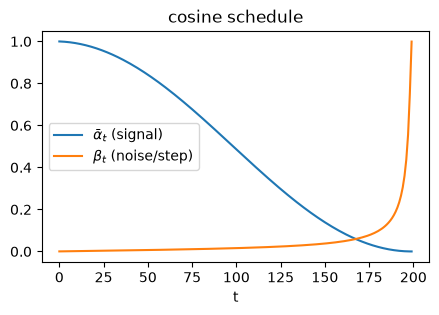

alpha_bar_T = 6.07e-08  (≈ 0, so x_T is ~pure noise)


In [3]:
T = 200                                    # number of diffusion steps

def cosine_betas(T, s=0.008):
    u = torch.linspace(0, T, T + 1)
    ab = torch.cos(((u / T + s) / (1 + s)) * math.pi / 2) ** 2
    ab = ab / ab[0]                                    # alpha_bar, normalized to 1 at t=0
    return (1 - ab[1:] / ab[:-1]).clamp(1e-8, 0.999)   # betas

betas = cosine_betas(T).to(device)
alphas = 1.0 - betas
alpha_bars = torch.cumprod(alphas, dim=0)              # how much signal survives to t
alpha_bars_prev = torch.cat([torch.ones(1, device=device), alpha_bars[:-1]])

plt.figure(figsize=(5, 3))
plt.plot(alpha_bars.cpu(), label=r"$\bar\alpha_t$ (signal)")
plt.plot(betas.cpu(), label=r"$\beta_t$ (noise/step)")
plt.xlabel("t"); plt.legend(); plt.title("cosine schedule"); plt.show()
print(f"alpha_bar_T = {alpha_bars[-1]:.2e}  (≈ 0, so x_T is ~pure noise)")

## 3 · The forward process (the "nice property")

Jump from a clean point straight to its noised version at any timestep in one shot:

$$x_t = \sqrt{\bar\alpha_t}\,x_0 + \sqrt{1-\bar\alpha_t}\,\varepsilon,\qquad \varepsilon\sim\mathcal N(0,I).$$

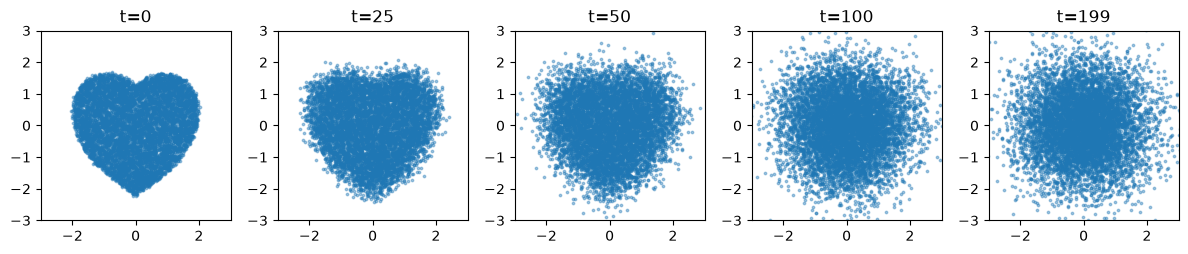

In [4]:
def add_noise(x0, t, noise):
    ab = alpha_bars[t].reshape(-1, 1)                  # (B, 1), broadcasts over the 2 coords
    return ab.sqrt() * x0 + (1 - ab).sqrt() * noise

# see it: the heart dissolving into noise
ts = [0, 25, 50, 100, 199]
fig, axes = plt.subplots(1, len(ts), figsize=(2.4 * len(ts), 2.4))
for ax, ti in zip(axes, ts):
    x_t = add_noise(data, torch.full((data.shape[0],), ti, device=device), torch.randn_like(data)).cpu()
    ax.scatter(x_t[:, 0], x_t[:, 1], s=3, alpha=0.4); ax.set_title(f"t={ti}")
    ax.set_xlim(-3, 3); ax.set_ylim(-3, 3); ax.set_aspect("equal")
plt.tight_layout(); plt.show()

## 4 · The network — a tiny MLP that predicts the noise

One network handles every noise level, so it takes the timestep as an input,
encoded with a sinusoidal embedding (a "bank of clocks"). It predicts the noise
$\varepsilon_\theta(x_t, t)$ that was added.

In [5]:
class SinusoidalTimeEmbedding(nn.Module):
    def __init__(self, dim):
        super().__init__(); self.dim = dim
    def forward(self, t):
        half = self.dim // 2
        freqs = torch.exp(-math.log(10000.0) * torch.arange(half, device=t.device) / (half - 1))
        args = t.float()[:, None] * freqs[None, :]
        return torch.cat([torch.sin(args), torch.cos(args)], dim=-1)

class MLPDenoiser(nn.Module):
    def __init__(self, data_dim=2, hidden=128, depth=4, time_dim=64):
        super().__init__()
        self.time_mlp = nn.Sequential(SinusoidalTimeEmbedding(time_dim),
                                      nn.Linear(time_dim, time_dim), nn.SiLU())
        layers = [nn.Linear(data_dim + time_dim, hidden), nn.SiLU()]
        for _ in range(depth - 1):
            layers += [nn.Linear(hidden, hidden), nn.SiLU()]
        layers += [nn.Linear(hidden, data_dim)]
        self.net = nn.Sequential(*layers)
    def forward(self, x, t):
        return self.net(torch.cat([x, self.time_mlp(t)], dim=-1))

model = MLPDenoiser().to(device)
print(model)
print(f"{sum(p.numel() for p in model.parameters()):,} parameters")

MLPDenoiser(
  (time_mlp): Sequential(
    (0): SinusoidalTimeEmbedding()
    (1): Linear(in_features=64, out_features=64, bias=True)
    (2): SiLU()
  )
  (net): Sequential(
    (0): Linear(in_features=66, out_features=128, bias=True)
    (1): SiLU()
    (2): Linear(in_features=128, out_features=128, bias=True)
    (3): SiLU()
    (4): Linear(in_features=128, out_features=128, bias=True)
    (5): SiLU()
    (6): Linear(in_features=128, out_features=128, bias=True)
    (7): SiLU()
    (8): Linear(in_features=128, out_features=2, bias=True)
  )
)
62,530 parameters


## 5 · The loss and the training loop

The DDPM objective is plain MSE between the true noise and the predicted noise:
noise a batch to random timesteps, ask the model for the noise, minimize the
error. Then the usual optimize loop.

step    0   loss 1.0390


step  500   loss 0.4730


step 1000   loss 0.4394


step 1500   loss 0.5110


step 2000   loss 0.4735


step 2500   loss 0.4919


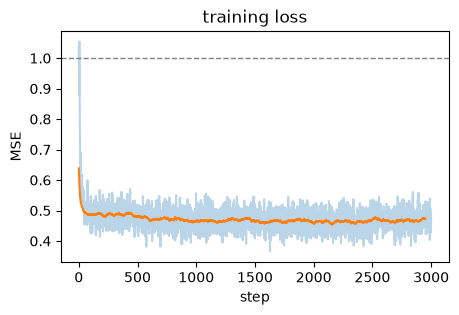

In [6]:
def ddpm_loss(model, x0):
    t = torch.randint(0, T, (x0.shape[0],), device=device)
    noise = torch.randn_like(x0)
    x_t = add_noise(x0, t, noise)
    return F.mse_loss(model(x_t, t), noise)

opt = torch.optim.Adam(model.parameters(), lr=2e-3)
losses = []
for step in range(3000):
    idx = torch.randint(0, data.shape[0], (512,), device=device)
    loss = ddpm_loss(model, data[idx])
    opt.zero_grad(); loss.backward(); opt.step()
    losses.append(loss.item())
    if step % 500 == 0:
        print(f"step {step:4d}   loss {loss.item():.4f}")

plt.figure(figsize=(5, 3))
plt.plot(losses, alpha=0.3)
plt.plot(torch.tensor(losses).unfold(0, 50, 1).mean(1), color="C1")
plt.axhline(1.0, ls="--", c="gray", lw=1); plt.xlabel("step"); plt.ylabel("MSE")
plt.title("training loss"); plt.show()

## 6 · Sampling — walk from pure noise back to data

Start from $x_T\sim\mathcal N(0,I)$ and reverse one step at a time: predict the
noise, form the posterior mean, add a little fresh noise (none on the final step).

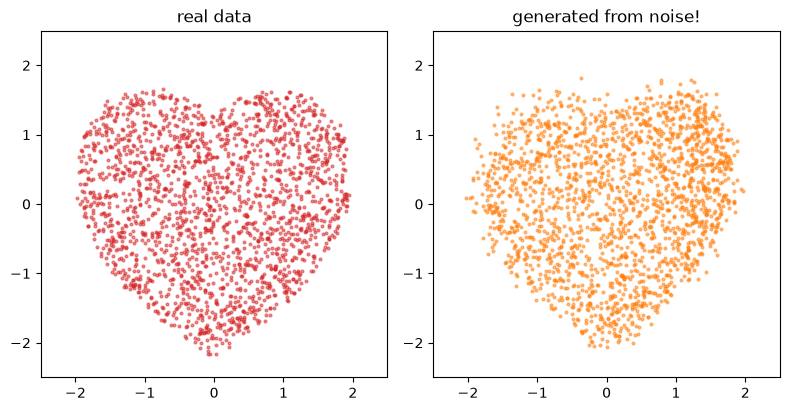

In [7]:
@torch.no_grad()
def sample(model, n, return_traj=False):
    x = torch.randn(n, 2, device=device)               # x_T ~ N(0, I)
    traj = [x.clone()]
    for step in reversed(range(T)):
        t = torch.full((n,), step, device=device, dtype=torch.long)
        eps = model(x, t)
        beta_t, alpha_t = betas[step], alphas[step]
        mean = (x - beta_t / (1 - alpha_bars[step]).sqrt() * eps) / alpha_t.sqrt()
        if step > 0:
            var = beta_t * (1 - alpha_bars_prev[step]) / (1 - alpha_bars[step])
            x = mean + var.sqrt() * torch.randn_like(x)
        else:
            x = mean                                    # final step: no noise
        if return_traj: traj.append(x.clone())
    return (x, traj) if return_traj else x

gen = sample(model, 2000).cpu()
real = data[:2000].cpu()
fig, (a1, a2) = plt.subplots(1, 2, figsize=(8, 4))
a1.scatter(real[:, 0], real[:, 1], s=4, alpha=0.5, color="C3"); a1.set_title("real data")
a2.scatter(gen[:, 0], gen[:, 1], s=4, alpha=0.5, color="C1"); a2.set_title("generated from noise!")
for a in (a1, a2): a.set_aspect("equal"); a.set_xlim(-2.5, 2.5); a.set_ylim(-2.5, 2.5)
plt.tight_layout(); plt.show()

## 7 · Watch it reform

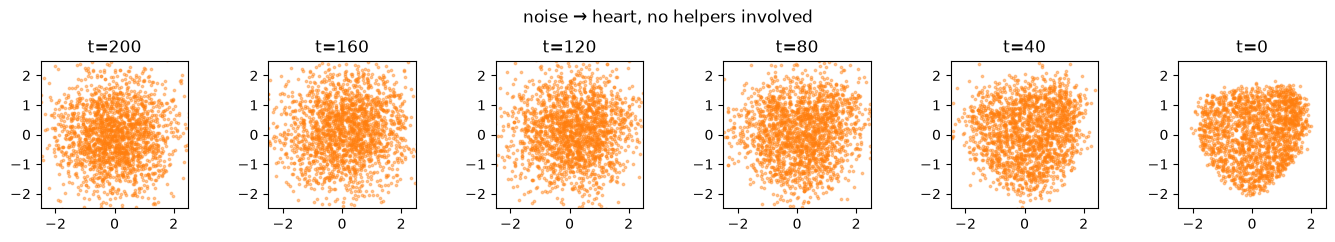

In [8]:
_, traj = sample(model, 2000, return_traj=True)
picks = [0, 40, 80, 120, 160, 200]
fig, axes = plt.subplots(1, len(picks), figsize=(2.3 * len(picks), 2.3))
for ax, i in zip(axes, picks):
    p = traj[i].cpu()
    ax.scatter(p[:, 0], p[:, 1], s=3, alpha=0.4, color="C1")
    ax.set_title(f"t={max(T - i, 0)}"); ax.set_xlim(-2.5, 2.5); ax.set_ylim(-2.5, 2.5); ax.set_aspect("equal")
plt.suptitle("noise → heart, no helpers involved"); plt.tight_layout(); plt.show()

## 🎉 That's a diffusion model — the whole thing

Scroll up. Everything between the imports and here — schedule, forward process,
network, loss, training, sampler — is **~130 lines of plain PyTorch**, no library
doing the diffusion for you. This is exactly what `nanodiffusion/` packages up, and
what the notebooks 01–03 had you build piece by piece; here it's assembled in one
readable file.

**What changes for real images (Part 2):** almost nothing in this structure — the
forward process, loss, and sampler stay identical. The one real swap is the
**network**: an MLP can't see spatial structure, so we replace it with a **U-Net**.
That's notebook 04.

> This notebook is also the blueprint for the repo's `train.py` / `sample.py` — the
> same code, minus the plots.